# HGS (Hypergraph Survival) Model Explanation Analysis

This notebook demonstrates how to perform explanation analysis on trained HGS models using Borda scores and triplets analysis.

In [1]:
import torch
import numpy as np
import pandas as pd
import logging
import os
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json



# Check CUDA availability
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    torch.cuda.set_device(0)

CUDA available: True
CUDA device: NVIDIA A100 80GB PCIe


In [ ]:
# Import project modules
import sys
sys.path.append('..')
os.chdir('..')
from utils.config_loader import ConfigLoader
from models.Models_interpret import HGS
from utils.data_utils import *
from utils.hg_ops import *
import torch.optim as optim
from HGS_XAI import (
    train_and_explain_model, 
    perform_triplets_analysis,
    get_borda_score_10seeds
)

print("All modules imported successfully!")
os.chdir('notebook')

All modules imported successfully!


## Configuration Setup

In [3]:
# Load configuration
config = ConfigLoader("../config.yaml")

# Get configurations
hardware_config = config.get_hardware_config()
data_config = config.get_data_config()
model_config = config.get_model_config()
path_config = config.get_paths()
print("=== Configuration Summary ===")
print(f"Hardware: {hardware_config}")
print(f"Data: {data_config}")
print(f"Model: {model_config}")
print(f"Path: {path_config}")

# Setup hardware
if hardware_config['use_cuda']:
    torch.cuda.set_device(hardware_config['cuda_device'])
    print(f"Using CUDA device: {hardware_config['cuda_device']}")

=== Configuration Summary ===
Hardware: {'cuda_device': 'cuda:0', 'use_cuda': True}
Data: {'type': 'PRO', 'knowledge_base': 'STRING', 'fcluster_method': 'weighted', 'datasets': ['HCC'], 'cox_num': 400, 'end_point': 'OS_60'}
Model: {'name': 'HGS', 'bayesian_optimization': True, 'n_trials': 20, 'judge_metric': 'best'}
Path: {'data_root': '/data/HGCluster_SC/data', 'proteomic_data_template': '/data/HGCluster_SC/data/PRO/{dataset}/dataset.csv', 'rna_data_template': '/data/HGCluster_SC/data/RNA/{dataset}/feature_matrix.csv', 'reactome_graph_template': '/data/HGCluster_SC/data/RNA/HCC/ReactomeGraph/reactome_P{layer}/', 'string_graph_template': '/data/HGCluster_SC/data/PRO/STRING/{method}/{dataset}-Level{layer}-H.csv', 'string_gene_list': '/data/HGCluster_SC/data/PRO/STRING/clusters.protein.ensg.csv', 'cluster_relation_file': '/data/HGCluster_SC/data/PRO/STRING/9606.clusters.tree.v12.0.txt', 'survival_data_template': '/data/HGCluster_SC/data/RNA/ClinicalDataFrame_DiscreteTime-Cut15Years.csv',

## Selected Model Parameters

Using the best hyperparameters from training results

In [4]:
# Selected hyperparameters for explanation analysis
DATA = "PRO"  # "RNA" or "PRO"
KNOW = "hcluster"  # "hcluster", "STRING", "Reactome"
dataset = "HCC"
Model = "HGS"
atten_type="single"

# Best hyperparameters from training
HD = {'AGG': 'cat', 'num_hgat': 'single', 'depth': 2, 'l2': 0.1, 'lr': 0.01, 'glr': 0, 'type_atten': 'additive', 
'n_hid': 200, 'gamma': 0.99, 'patience': 5, 'update_freq': 1, 'score': 'harmonic score', 'metric_update': 'score', 
'train_scheme': 'final_epoch', 'MLP_hiddens': [200], 'predict_hiddens': [200, 100], 'model': 'HGS', 'dataset': 'HCC', 
'epochs': 50, 'print_freq': 10, 'batch_size': 32, 'cox_num': 400, 'dropout': 0.5, 'ACT': 'LeakyReLU', 
'pooling_hiddens': [59, 5], 'RESNET': False, 'repeat_time': 10, 'end_point': 'OS_60', 'edge_pooling': True, 
'loss_w': {'a': 1, 'b': 1, 'c1': 1, 'c2': 0, 'd': 1}, 'pooling_method': 'linear', 'n_trials': 20, 'BayeOpt': False, 
'JM': 'final', 'feature_base': 'STRING', 'num_min': 25, 'HG_BN': True, 'n_hp_ckpt': 11,	"atten_type": atten_type,'seed':7}
PK_D= {'type_know': 'hcluster', 'method': 'weighted', 'criterion': 'maxclust', 'num_clusters': 59, 'divisor': 10, 'DataDrive': 'hcluster'}

print(f"Selected parameters for {DATA}-{dataset}-{KNOW}:")
print(f"HD: {HD}")
print(f"PK_D: {PK_D}")

Selected parameters for PRO-HCC-hcluster:
HD: {'AGG': 'cat', 'num_hgat': 'single', 'depth': 2, 'l2': 0.1, 'lr': 0.01, 'glr': 0, 'type_atten': 'additive', 'n_hid': 200, 'gamma': 0.99, 'patience': 5, 'update_freq': 1, 'score': 'harmonic score', 'metric_update': 'score', 'train_scheme': 'final_epoch', 'MLP_hiddens': [200], 'predict_hiddens': [200, 100], 'model': 'HGS', 'dataset': 'HCC', 'epochs': 50, 'print_freq': 10, 'batch_size': 32, 'cox_num': 400, 'dropout': 0.5, 'ACT': 'LeakyReLU', 'pooling_hiddens': [59, 5], 'RESNET': False, 'repeat_time': 10, 'end_point': 'OS_60', 'edge_pooling': True, 'loss_w': {'a': 1, 'b': 1, 'c1': 1, 'c2': 0, 'd': 1}, 'pooling_method': 'linear', 'n_trials': 20, 'BayeOpt': False, 'JM': 'final', 'feature_base': 'STRING', 'num_min': 25, 'HG_BN': True, 'n_hp_ckpt': 11, 'atten_type': 'single', 'seed': 7}
PK_D: {'type_know': 'hcluster', 'method': 'weighted', 'criterion': 'maxclust', 'num_clusters': 59, 'divisor': 10, 'DataDrive': 'hcluster'}


## Data Loading

In [5]:
# Load data based on configuration
data_root = path_config['data_root']
# data, H = load_data_general(data_config['type'], PK_D, HD, config.get_data_path(dataset), config)
if DATA == 'PRO':
    dn_data = f"{path_config['proteomic_data_template'].format(data_root=data_root, dataset=dataset)}"
    data, H = load_cohort_data(None, dn_data , HD['cox_num'], DF=True)
elif DATA == 'RNA':
    dn_data = f"{path_config['rna_data_template'].format(data_root=data_root, dataset=dataset)}"
    if PK_D["type_know"] == 'hcluster':
        # TODO: Implement for hcluster RNA data
        pass
    else:
        H_path = f"{path_config['reactome_graph_template'].format(data_root=data_root, layer=PK_D['layer_Reactome'])}"
        data, H_df = load_opt_data(data_path=dn_data, H_path=H_path, endpoint="OS_60", Filt_num=HD['cox_num'], DF=True)

print(f"Data loaded: {data.shape}")


Data loaded: (412, 402)


## Setup Output Directory

In [6]:
# Create output directory following the architecture pattern
out_path = f"../Results/Interpret/{DATA}-{dataset}-{KNOW}/"
out_path += str(list(HD.items())[:HD['n_hp_ckpt']]).replace("), (", "-").replace(",", ":").replace("'", "").replace(" ", "")[2:-2]
out_path += "-" + str(list(PK_D.items())).replace("), (", "-").replace(",", ":").replace("'", "").replace(" ", "")[2:-2]
os.makedirs(out_path, exist_ok=True)

fn_ckpt = out_path + f"/{Model}-{dataset}"

print(f"Output directory: {out_path}")
print(f"Checkpoint file: {fn_ckpt}")

Output directory: ../Results/Interpret/PRO-HCC-hcluster/AGG:cat-num_hgat:single-depth:2-l2:0.1-lr:0.01-glr:0-type_atten:additive-n_hid:200-gamma:0.99-patience:5-update_freq:1-type_know:hcluster-method:weighted-criterion:maxclust-num_clusters:59-divisor:10-DataDrive:hcluster
Checkpoint file: ../Results/Interpret/PRO-HCC-hcluster/AGG:cat-num_hgat:single-depth:2-l2:0.1-lr:0.01-glr:0-type_atten:additive-n_hid:200-gamma:0.99-patience:5-update_freq:1-type_know:hcluster-method:weighted-criterion:maxclust-num_clusters:59-divisor:10-DataDrive:hcluster/HGS-HCC


## Model Training and Explanation Analysis

2025-08-01 04:28:23,989 - HGS_Explain - INFO - H:(400, 59); data:(412, 402); G:(59, 59); t_obs:44.0
2025-08-01 04:28:23,991 - HGS_Explain - INFO - Pooling_hiddens:[59, 5]



Hyperedges computed by Pearson-Hcluster= 59


2025-08-01 04:28:26,217 - HGS_Explain - INFO - --------------------
2025-08-01 04:28:26,220 - HGS_Explain - INFO - Epoch 0/50
2025-08-01 04:28:26,543 - HGS_Explain - INFO - Updating eval ci: 0.627781; eval loss: 50.939499
2025-08-01 04:28:28,696 - HGS_Explain - INFO - --------------------
2025-08-01 04:28:28,698 - HGS_Explain - INFO - Epoch 10/50
2025-08-01 04:28:29,027 - HGS_Explain - INFO - Updating eval ci: 0.779916; eval loss: 54.143967
2025-08-01 04:28:30,643 - HGS_Explain - INFO - --------------------
2025-08-01 04:28:30,645 - HGS_Explain - INFO - Epoch 20/50
2025-08-01 04:28:30,858 - HGS_Explain - INFO - Updating eval ci: 0.764883; eval loss: 53.428493
2025-08-01 04:28:33,156 - HGS_Explain - INFO - --------------------
2025-08-01 04:28:33,158 - HGS_Explain - INFO - Epoch 30/50
2025-08-01 04:28:33,523 - HGS_Explain - INFO - Updating eval ci: 0.743836; eval loss: 52.011070
2025-08-01 04:28:35,532 - HGS_Explain - INFO - --------------------
2025-08-01 04:28:35,536 - HGS_Explain - I

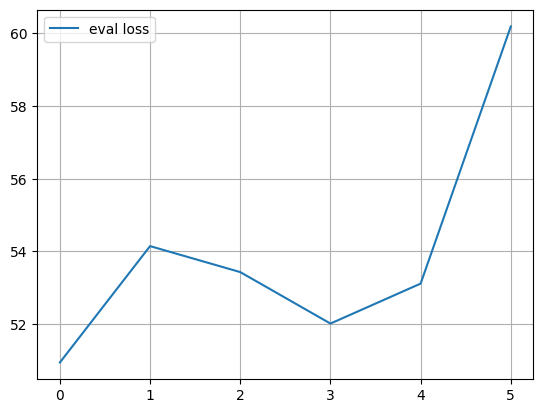

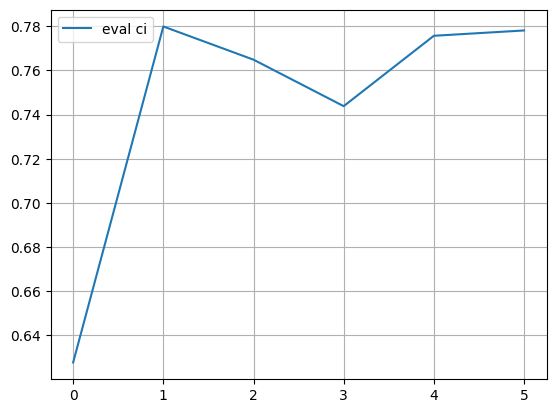

Top 0 hyperedges removed, test CI: 0.7768488745980707
Bottom 0 hyperedges removed, test CI: 0.7768488745980707
Top 5 hyperedges removed, test CI: 0.7742765273311897
Bottom 5 hyperedges removed, test CI: 0.7781350482315113
Top 11 hyperedges removed, test CI: 0.7511254019292605
Bottom 11 hyperedges removed, test CI: 0.77491961414791
Top 17 hyperedges removed, test CI: 0.735048231511254
Bottom 17 hyperedges removed, test CI: 0.7659163987138263
Top 23 hyperedges removed, test CI: 0.7292604501607717
Bottom 23 hyperedges removed, test CI: 0.752411575562701
Top 29 hyperedges removed, test CI: 0.7209003215434083
Bottom 29 hyperedges removed, test CI: 0.7408360128617363
Top 0 nodes removed, test CI: 0.7768488745980707
Bottom 0 nodes removed, test CI: 0.7768488745980707
Top 40 nodes removed, test CI: 0.7717041800643086
Bottom 40 nodes removed, test CI: 0.7755627009646302
Top 80 nodes removed, test CI: 0.7620578778135049
Bottom 80 nodes removed, test CI: 0.7742765273311897
Top 120 nodes removed, 

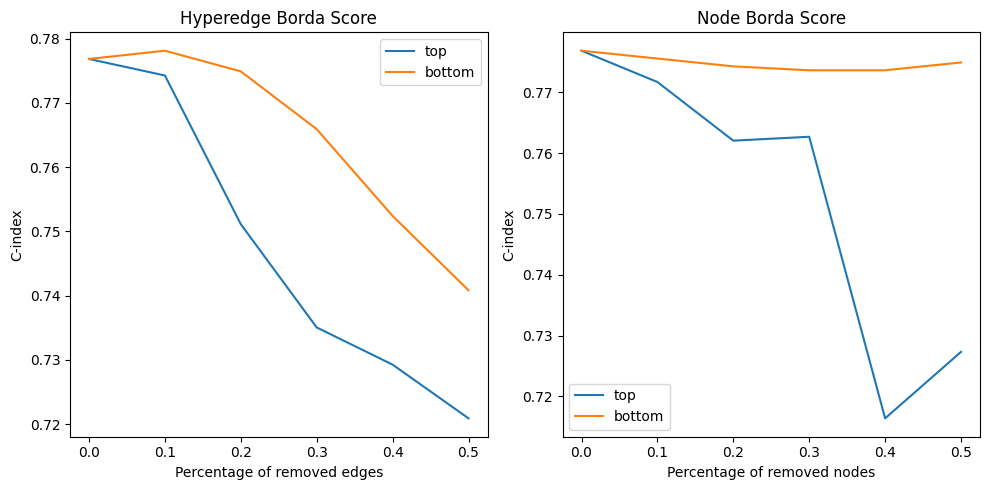

In [7]:
# Setup logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')
logger = logging.getLogger(f"HGS_Explain")

# Train model and perform explanation analysis
model, node_borda, hyperedge_borda, data_train, data_test, H_df = train_and_explain_model(
    HD, PK_D, dataset, data, Model, DATA, out_path, fn_ckpt, HD['seed'], logger
)

print("Model training and explanation analysis completed!")

## Triplets Analysis

In [ ]:
# Perform triplets analysis
n_triplets = 30
fn_map = config.get_paths()['mart_export'].format(data_root=data_root)
dn_esdb = config.get_paths()['gsva_dir'].format(data_root=data_root)

TA, bordas_dict, triplets_statistics = perform_triplets_analysis(
    model, H_df, data, out_path, str(Path(dn_data).parent), hyperedge_borda, node_borda,
    n_triplets, PK_D, fn_map, dn_esdb
)

print("Triplets analysis completed!")
print(f"Number of triplets analyzed: {n_triplets}")
print(f"Results saved to: {out_path}")

2025-08-01 04:28:51,376 - utils.Interpret - INFO - using existing file: ../Results/Interpret/PRO-HCC-hcluster/AGG:cat-num_hgat:single-depth:2-l2:0.1-lr:0.01-glr:0-type_atten:additive-n_hid:200-gamma:0.99-patience:5-update_freq:1-type_know:hcluster-method:weighted-criterion:maxclust-num_clusters:59-divisor:10-DataDrive:hcluster/ClusterGSEA/0.csv
2025-08-01 04:28:51,381 - utils.Interpret - INFO - using existing file: ../Results/Interpret/PRO-HCC-hcluster/AGG:cat-num_hgat:single-depth:2-l2:0.1-lr:0.01-glr:0-type_atten:additive-n_hid:200-gamma:0.99-patience:5-update_freq:1-type_know:hcluster-method:weighted-criterion:maxclust-num_clusters:59-divisor:10-DataDrive:hcluster/ClusterGSEA/1.csv
2025-08-01 04:28:51,386 - utils.Interpret - INFO - using existing file: ../Results/Interpret/PRO-HCC-hcluster/AGG:cat-num_hgat:single-depth:2-l2:0.1-lr:0.01-glr:0-type_atten:additive-n_hid:200-gamma:0.99-patience:5-update_freq:1-type_know:hcluster-method:weighted-criterion:maxclust-num_clusters:59-divisor

(liver neoplasm[mh])
Integration of Viral DNA Into Host Genomic DNA AND (liver neoplasm[mh])


2025-08-01 04:29:17,538 - utils.Interpret - INFO - calculating HRs for integration of viral dna into host genomic dna pathways by cox univariate regression


['ES']
Cox univariate regression for computing hr...
using multiprocessing...


  0%|          | 0/1 [00:00<?, ?it/s]


...

['ES']
Cox univariate regression for computing hr...
using multiprocessing...


  0%|          | 0/1 [00:00<?, ?it/s]


multiprocessing error,using for loop...


2025-08-01 04:39:50,170 - utils.Interpret - INFO - {
    "cancer name": "liver neoplasm",
    "gene name": "TP53RK",
    "biological_process name": "tRNA Threonylcarbamoyladenosine Metabolic Process (GO:0070525)",
    "XAI scores of gene 'TP53RK' and biological_process 'tRNA Threonylcarbamoyladenosine Metabolic Process (GO:0070525)' in 'liver neoplasm' cancer": 2.7288135593220337,
    "Papers count of gene 'TP53RK' and biological_process 'tRNA Threonylcarbamoyladenosine Metabolic Process (GO:0070525)' and 'liver neoplasm' cancer in Pubmed": {
        "papers count of cancer-gene-biological_process": 0,
        "papers count of gene-biological_process": 0,
        "papers count of cancer-gene": 2,
        "papers count of cancer-biological_process": 1
    },
    "gene 'TP53RK' bioinformatics statistics indicators": "cox hazard ratio for gene expression: 0.5397175182319218; cox p value for gene expression: 0.0001141625497421;",
    "gene 'TP53RK' and biological_process 'trna threonylcarb

Triplets analysis completed!
Number of triplets analyzed: 30
Results saved to: ../Results/Interpret/PRO-HCC-hcluster/AGG:cat-num_hgat:single-depth:2-l2:0.1-lr:0.01-glr:0-type_atten:additive-n_hid:200-gamma:0.99-patience:5-update_freq:1-type_know:hcluster-method:weighted-criterion:maxclust-num_clusters:59-divisor:10-DataDrive:hcluster


## Results Visualization

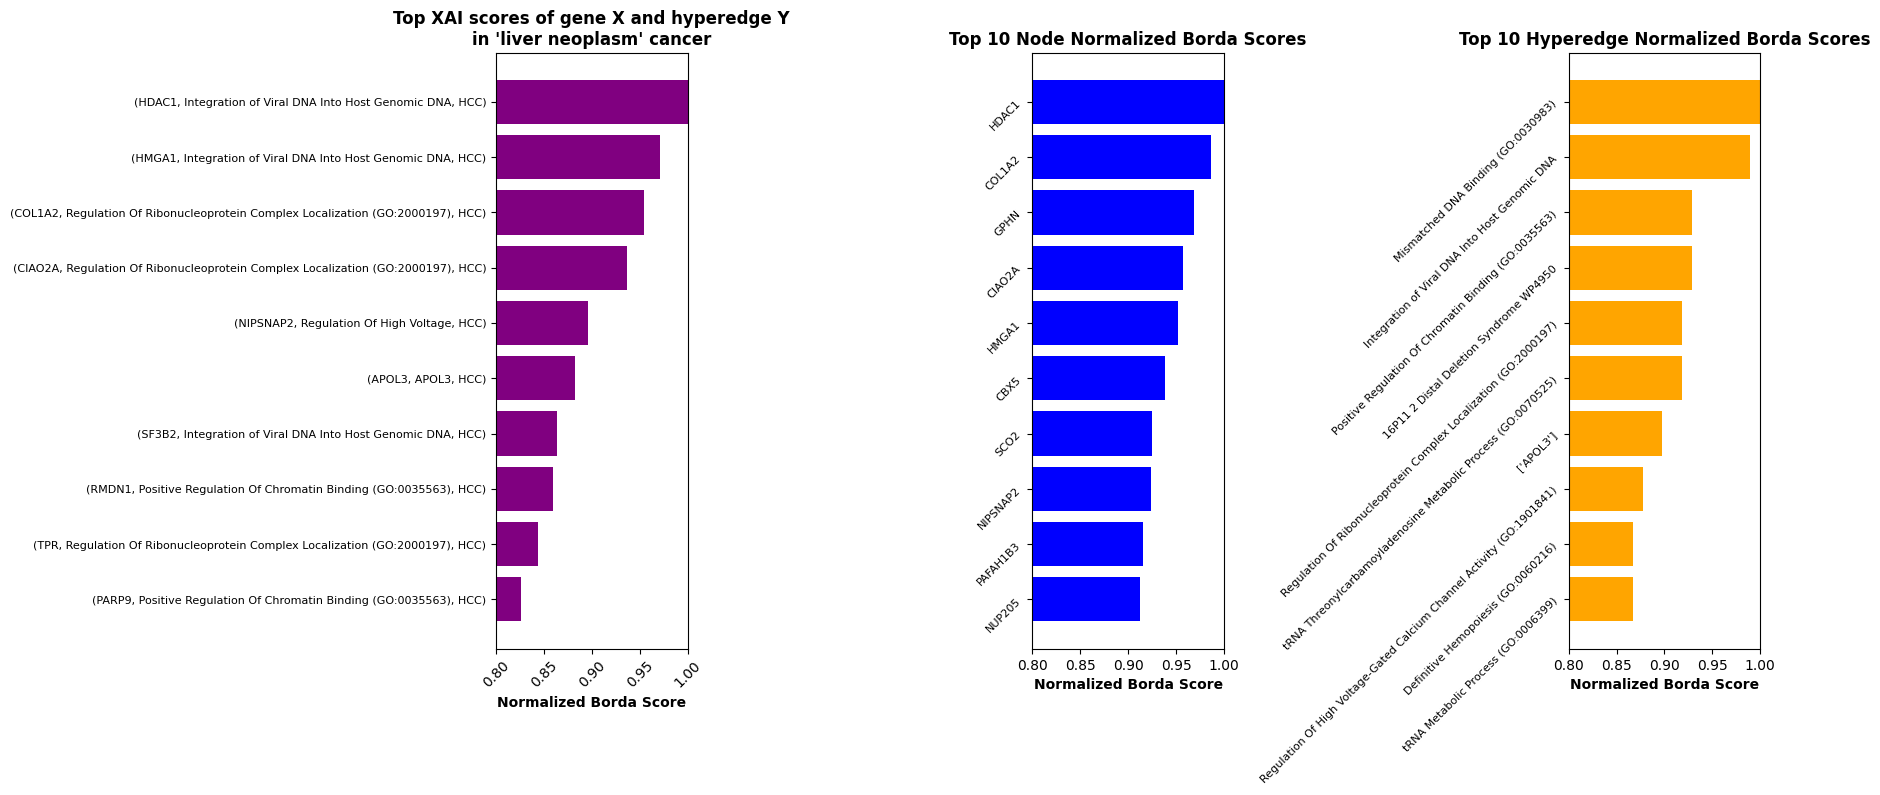

In [16]:
# Visualize Borda scores distribution (3 subplots, xticks rotation 45, bold font for labels, xticks start from 0.8)
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# Plot 1: Top XAI scores of gene X and hyperedge Y in 'liver neoplasm' cancer
pair_borda = np.array(bordas_dict['pair_borda'])
pair_name = np.array(bordas_dict['pair_name'])
top_n = 10
top_triplet_indices = np.argsort(pair_borda)[-top_n:]
top_triplet_scores = pair_borda[top_triplet_indices]
top_triplet_scores_norm = (top_triplet_scores - pair_borda.min()) / (pair_borda.max() - pair_borda.min() + 1e-8)
top_triplet_names = pair_name[top_triplet_indices]

def parse_triplet_label(triplet_str):
    try:
        gene = triplet_str.split('-')[0].replace('[','').replace(']','').replace("'","").strip()
        hyperedge = triplet_str.split('-')[1].replace('[','').replace(']','').replace("'","").strip()
    except Exception:
        gene, hyperedge = triplet_str, ""
    return f"({gene}, {hyperedge}, HCC)"

yticklabels = [parse_triplet_label(n) for n in top_triplet_names]

axes[0].barh(range(top_n), top_triplet_scores_norm, color='purple')
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(yticklabels, fontsize=8)
axes[0].set_xlabel('Normalized Borda Score', fontweight='bold')
axes[0].set_title("Top XAI scores of gene X and hyperedge Y\nin 'liver neoplasm' cancer", fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_xlim(left=0.8, right=1.0)

# Plot 2: Top node names (normalized Borda score)
top_node_indices = np.argsort(node_borda)[-10:]
top_node_names = [TA.node_name[i] for i in top_node_indices]
top_node_scores = np.array([node_borda[i] for i in top_node_indices])
node_borda_min = np.min(node_borda)
node_borda_max = np.max(node_borda)
top_node_scores_norm = (top_node_scores - node_borda_min) / (node_borda_max - node_borda_min + 1e-8)
axes[1].barh(range(len(top_node_names)), top_node_scores_norm, color='blue')
axes[1].set_yticks(range(len(top_node_names)))
axes[1].set_yticklabels(top_node_names, fontsize=8)
axes[1].set_title('Top 10 Node Normalized Borda Scores', fontweight='bold')
axes[1].set_xlabel('Normalized Borda Score', fontweight='bold')
axes[1].tick_params(axis='y', rotation=45)
axes[1].set_xlim(left=0.8, right=1.0)

# Plot 3: Top hyperedge names (normalized Borda score)
top_hyperedge_indices = np.argsort(hyperedge_borda)[-10:]
top_hyperedge_names = [TA.hyperedge_name[i] for i in top_hyperedge_indices]
top_hyperedge_scores = np.array([hyperedge_borda[i] for i in top_hyperedge_indices])
hyperedge_borda_min = np.min(hyperedge_borda)
hyperedge_borda_max = np.max(hyperedge_borda)
top_hyperedge_scores_norm = (top_hyperedge_scores - hyperedge_borda_min) / (hyperedge_borda_max - hyperedge_borda_min + 1e-8)
axes[2].barh(range(len(top_hyperedge_names)), top_hyperedge_scores_norm, color='orange')
axes[2].set_yticks(range(len(top_hyperedge_names)))
axes[2].set_yticklabels(top_hyperedge_names, fontsize=8)
axes[2].set_title('Top 10 Hyperedge Normalized Borda Scores', fontweight='bold')
axes[2].set_xlabel('Normalized Borda Score', fontweight='bold')
axes[2].tick_params(axis='y', rotation=45)
axes[2].set_xlim(left=0.8, right=1.0)

plt.tight_layout()
plt.savefig(f'{out_path}/borda_scores_analysis.svg', bbox_inches='tight')
plt.show()

## Summary Statistics

In [17]:
# Print summary statistics
print("=== Explanation Analysis Summary ===")
print(f"Dataset: {DATA}-{dataset}-{KNOW}")
print(f"Model: {Model}")
print(f"Output directory: {out_path}")
print(f"\nBorda Score Statistics:")
print(f"  Node Borda Scores:")
print(f"    Mean: {np.mean(node_borda):.4f}")
print(f"    Std: {np.std(node_borda):.4f}")
print(f"    Min: {np.min(node_borda):.4f}")
print(f"    Max: {np.max(node_borda):.4f}")
print(f"  Hyperedge Borda Scores:")
print(f"    Mean: {np.mean(hyperedge_borda):.4f}")
print(f"    Std: {np.std(hyperedge_borda):.4f}")
print(f"    Min: {np.min(hyperedge_borda):.4f}")
print(f"    Max: {np.max(hyperedge_borda):.4f}")
print(f"   Pair Borda Scores:")
print(f"    Mean: {np.mean(pair_borda):.4f}")
print(f"    Std: {np.std(pair_borda):.4f}")
print(f"    Min: {np.min(pair_borda):.4f}")
print(f"    Max: {np.max(pair_borda):.4f}")
print(f"\nTriplets Analysis:")
print(f"  Number of triplets: {n_triplets}")
print(f"  Statistics saved to: {out_path}/{n_triplets}triplets_statistics.json")
print(f"  Borda scores saved to: {out_path}/bordas_dict.json")

=== Explanation Analysis Summary ===
Dataset: PRO-HCC-hcluster
Model: HGS
Output directory: ../Results/Interpret/PRO-HCC-hcluster/AGG:cat-num_hgat:single-depth:2-l2:0.1-lr:0.01-glr:0-type_atten:additive-n_hid:200-gamma:0.99-patience:5-update_freq:1-type_know:hcluster-method:weighted-criterion:maxclust-num_clusters:59-divisor:10-DataDrive:hcluster

Borda Score Statistics:
  Node Borda Scores:
    Mean: 401.0000
    Std: 157.7952
    Min: 29.0000
    Max: 775.0000
  Hyperedge Borda Scores:
    Mean: 60.0000
    Std: 26.8050
    Min: 12.0000
    Max: 110.0000
   Pair Borda Scores:
    Mean: 1.7175
    Std: 0.6113
    Min: 0.6318
    Max: 3.7850

Triplets Analysis:
  Number of triplets: 30
  Statistics saved to: ../Results/Interpret/PRO-HCC-hcluster/AGG:cat-num_hgat:single-depth:2-l2:0.1-lr:0.01-glr:0-type_atten:additive-n_hid:200-gamma:0.99-patience:5-update_freq:1-type_know:hcluster-method:weighted-criterion:maxclust-num_clusters:59-divisor:10-DataDrive:hcluster/30triplets_statistics.jso